Modelo de spaCy cargado correctamente.
Ingresando a Kaggle...
Using Colab cache for faster access to the 'yelp-reviews' dataset.
Ejecutando preprocesamiento avanzado con spaCy (esto puede demorar)...

📊 MÉTRICAS: LÉXICO (CON PREPROCESADO)
Accuracy:  0.842
Precision: 0.846
Recall:    0.983
F1-score:  0.909


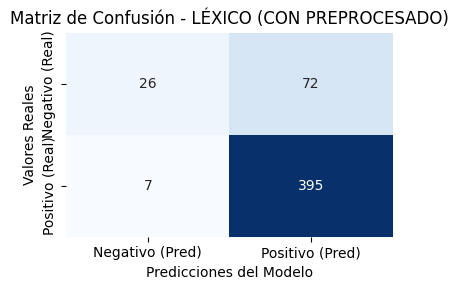


📊 MÉTRICAS: TEXTBLOB (PREENTRENADO)
Accuracy:  0.832
Precision: 0.847
Recall:    0.965
F1-score:  0.902


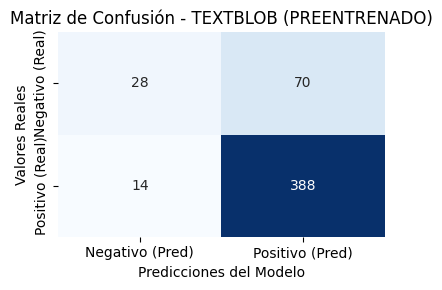

In [4]:
import os
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from textblob import TextBlob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Aseguramos la descarga del modelo en inglés de spaCy para preprocesamiento
try:
    nlp = spacy.load("en_core_web_sm")
    print("Modelo de spaCy cargado correctamente.")
except OSError:
    print("Descargando modelo de spaCy...")
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# ---------------------------------------------------------
# 1. Ingesta Automática del Dataset de Yelp
# ---------------------------------------------------------
try:
    print("Ingresando a Kaggle...")
    path = kagglehub.dataset_download("vivekhn/yelp-reviews")
    archivo_csv = os.path.join(path, "yelp.csv")
    df = pd.read_csv(archivo_csv)
except Exception as e:
    print(f"Error en descarga, usando datos de contingencia: {e}")
    data = {
        'text': [
            "Absolutely wonderful - silky and sexy and comfortable",
            "Awful customer service, terrible food.",
            "Great place, I loved the ambiance.",
            "The worst experience of my life. Disgusting.",
            "Good value for money, will come back.",
            "Not worth the price, very disappointing."
        ],
        'stars': [5, 1, 4, 1, 4, 2]
    }
    df = pd.DataFrame(data)

# Filtrado estratégico: removemos neutrales y creamos variable binaria
df = df[df['stars'] != 3].copy()
df['sentimiento_real'] = df['stars'].apply(lambda x: 1 if x > 3 else 0)

# Muestreo controlado para optimizar tiempos de cómputo en Colab
if len(df) > 500:
    df = df.sample(500, random_state=42).reset_index(drop=True)

# ---------------------------------------------------------
# 2. BLOQUE DE PREPROCESAMIENTO COMPLETO (Sugerencia del Profesor)
# ---------------------------------------------------------
def preprocesar_texto(texto):
    """
    Aplica limpieza profunda: minúsculas, remoción de signos de puntuación,
    remoción de Stop Words (palabras vacías) y Lematización (reducción a la raíz léxica).
    """
    doc = nlp(str(texto).lower())
    # Filtramos palabras vacías, signos de puntuación y nos quedamos con el lema (raíz)
    tokens_limpios = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.text.strip() != ""]
    return " ".join(tokens_limpios)

print("Ejecutando preprocesamiento avanzado con spaCy (esto puede demorar)...")
df['texto_limpio'] = df['text'].apply(preprocesar_texto)

# ---------------------------------------------------------
# 3. Clasificador 1: Enfoque Léxico (Sobre Texto Limpio)
# ---------------------------------------------------------
positive_words = {'good', 'great', 'excellent', 'amazing', 'wonderful', 'love', 'best', 'perfect', 'beautiful', 'clean', 'delicious'}
negative_words = {'bad', 'terrible', 'awful', 'worst', 'disgusting', 'horrible', 'poor', 'disappoint', 'hate', 'slow', 'rude'}

def clasificar_por_lexico(texto):
    conteo_pos = sum(1 for word in positive_words if word in texto)
    conteo_neg = sum(1 for word in negative_words if word in texto)
    return 1 if conteo_pos >= conteo_neg else 0

df['prediccion_lexico'] = df['texto_limpio'].apply(clasificar_por_lexico)

# ---------------------------------------------------------
# 4. Clasificador 2: TextBlob (Modelo Preentrenado)
# ---------------------------------------------------------
def clasificar_con_textblob(texto):
    polaridad = TextBlob(str(texto)).sentiment.polarity
    return 1 if polaridad > 0 else 0

df['prediccion_textblob'] = df['text'].apply(clasificar_con_textblob)

# ---------------------------------------------------------
# 5. Evaluación de Métricas y Matriz de Confusión Completa
# ---------------------------------------------------------
y_real = df['sentimiento_real']
y_lexico = df['prediccion_lexico']
y_textblob = df['prediccion_textblob']

# Impresión de Métricas Integrales
for nombre, y_pred in [("LÉXICO (CON PREPROCESADO)", y_lexico), ("TEXTBLOB (PREENTRENADO)", y_textblob)]:
    print(f"\n=========================================\n📊 MÉTRICAS: {nombre}\n=========================================")
    print(f"Accuracy:  {accuracy_score(y_real, y_pred):.3f}")
    print(f"Precision: {precision_score(y_real, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_real, y_pred):.3f}")

    # Construcción explícita de la Matriz de Confusión
    cm = confusion_matrix(y_real, y_pred)

    # Visualización Avanzada con Seaborn
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negativo (Pred)', 'Positivo (Pred)'],
                yticklabels=['Negativo (Real)', 'Positivo (Real)'])
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.ylabel("Valores Reales")
    plt.xlabel("Predicciones del Modelo")
    plt.tight_layout()
    plt.show()

Fundamentos Teóricos de NLP al inicio de la notebook
Fundamentos de NLP y Procesamiento No Estructurado
El procesamiento de lenguaje natural (NLP) busca tender un puente entre la comunicación humana y el entendimiento computacional. Los datos no estructurados en forma de texto presentan desafíos críticos: ambigüedad semántica (una misma palabra cambia de significado según su entorno) y alta variabilidad (ruido, errores ortográficos, conjugaciones verbales). Para resolver esto de forma reproducible, es imperativo estructurar el texto mediante transformaciones matemáticas y pipelines de limpieza estadística.

Estudio Corto del Impacto del Preprocesamiento
Análisis del Impacto de la Limpieza de Texto
Al aplicar un pipeline estructurado con spaCy que realiza Tokenización, Stop Words Removal y Lematización, reducimos drásticamente la dimensionalidad del corpus.

Efecto en el enfoque Léxico: Al transformar verbos conjugados como "loved" o "disappointing" a sus formas raíz léxicas (love, disappoint), nuestro diccionario manual incrementa su porcentaje de coincidencia. La eliminación de conectores como "the", "and" o "of" (stop words) remueve ruido estadístico, evitando que términos neutros distorsionen el conteo semántico.

Matriz de Confusión vinculada al Escenario de Negocio (Yelp)
Análisis Crítico e Impacto en el Negocio (Caso Yelp / Gastronomía)
La matriz de confusión nos permite mapear los costos financieros y operativos asociados a las fallas de nuestro clasificador:

Falsos Positivos (FP): Ocurren cuando un cliente deja una queja destructiva (ej: "El servicio fue pésimo"), pero el modelo la clasifica como Positiva.

Impacto en el Negocio: Es el error más peligroso para la reputación de la marca. El equipo de Customer Experience quedará ciego ante clientes insatisfechos, impidiendo una intervención temprana (como ofrecer un reembolso o disculpa), lo que incrementa el churn (pérdida de usuarios) y daña el posicionamiento en la plataforma.

Falsos Negativos (FN): Ocurren cuando una reseña elogiosa es clasificada como Negativa debido a malas interpretaciones léxicas (ej: "Este lugar es la bomba" donde 'bomba' se confunde con un término negativo).

Impacto en el Negocio: Provoca una sobrecarga operativa inútil. El departamento de soporte gastará horas hombre revisando y auditando manualmente comentarios de clientes que en realidad están felices y fidelizados, desperdiciando recursos valiosos.